# Hydro-Sense — Pipeline Machine Learning avec Darts

**Projet Le Wagon Data Science & AI — Nantes, juin 2026**

---

## Objectif
Predire le niveau des nappes phreatiques a **t+90 jours** sur le piezometre de Bourdet (Deux-Sevres, 79).

## Donnees
- Source : `piezo_bourdet_clean.csv` — donnees journalieres 1994 a 2026
- Cible : `niveau_nappe_eau` en **m NGF**

## Plan du notebook
1. Chargement & audit des donnees
2. Construction de la TimeSeries Darts
3. Split train / val
4. Baselines (Naif, Saisonnier, Moyenne)
5. LinearRegression avec lags
6. XGBoost avec lags
7. Comparaison finale & conclusions


---
## 1. Chargement & audit des donnees

On verifie la qualite du CSV nettoye avant de modeliser.

**Checks :**
- Shape, types
- Valeurs manquantes & doublons
- Continuite temporelle (pas de trous)
- Valeurs aberrantes (outliers)


In [1]:
import pandas as pd

df = pd.read_csv("./data/piezo_bourdet_clean.csv")

df.head()

,date_mesure,niveau_nappe_eau
0,1994-02-01,13.45
1,1994-02-02,13.55
2,1994-02-03,13.79
3,1994-02-04,13.80
4,1994-02-05,13.79


In [2]:
df.shape

(11807, 2)

In [3]:
df.isna().sum()

date_mesure         0
niveau_nappe_eau    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.describe()

,niveau_nappe_eau
count,11807.000000
mean,12.232256
std,1.179577
min,7.370000
25%,11.710000
50%,12.470000
75%,12.970000
max,14.620000


In [6]:
df["date_mesure"] = pd.to_datetime(df["date_mesure"])

### Continuite temporelle
`diff()` calcule l'ecart en jours entre chaque date et la precedente.
`(gaps > 1).sum()` compte les trous de plus d'un jour.


In [7]:
# check si trous

gaps = df["date_mesure"].diff().dt.days
(gaps>1).sum()

np.int64(0)

### Detection des valeurs aberrantes
Regle IQR : on flagge les valeurs a plus de **3xIQR** de Q1/Q3.
Pour une serie hydrologique, un outlier n'est pas forcement une erreur — ca peut etre un evenement extreme reel.


=== DISTRIBUTION niveau_nappe_eau ===
count    11807.000000
mean        12.232256
std          1.179577
min          7.370000
25%         11.710000
50%         12.470000
75%         12.970000
max         14.620000
Name: niveau_nappe_eau, dtype: float64

Outliers (règle 3×IQR) : 46 lignes


,date_mesure,niveau_nappe_eau
552,1995-08-07,7.92
553,1995-08-08,7.90
554,1995-08-09,7.88
555,1995-08-10,7.87
556,1995-08-11,7.84
557,1995-08-12,7.81
558,1995-08-13,7.78
559,1995-08-14,7.76
560,1995-08-15,7.74
561,1995-08-16,7.70


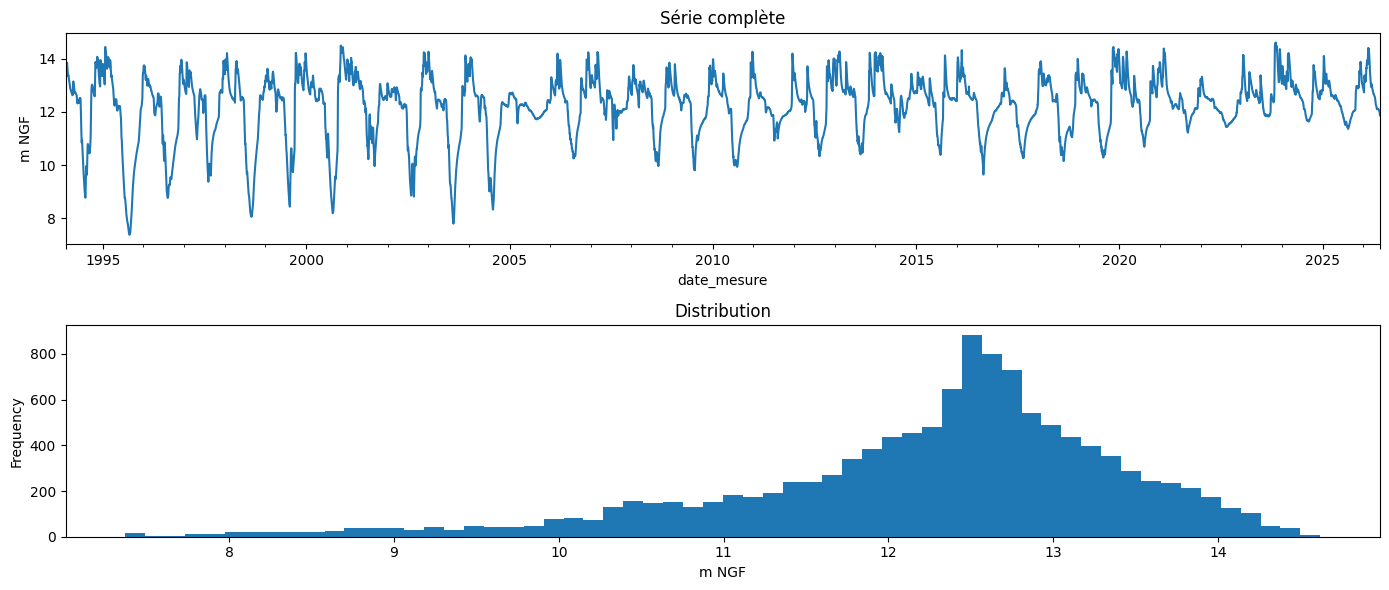

In [8]:
import matplotlib.pyplot as plt

# check valeurs aberrantes

# --- Outliers ---
print("=== DISTRIBUTION niveau_nappe_eau ===")
print(df["niveau_nappe_eau"].describe())

Q1 = df["niveau_nappe_eau"].quantile(0.25)
Q3 = df["niveau_nappe_eau"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["niveau_nappe_eau"] < Q1 - 3*IQR) | (df["niveau_nappe_eau"] > Q3 + 3*IQR)]
print(f"\nOutliers (règle 3×IQR) : {len(outliers)} lignes")
if len(outliers) > 0:
    display(outliers)

# --- Visualisation rapide ---
fig, axes = plt.subplots(2, 1, figsize=(14, 6))

df.set_index("date_mesure")["niveau_nappe_eau"].plot(ax=axes[0], title="Série complète")
axes[0].set_ylabel("m NGF")

df.set_index("date_mesure")["niveau_nappe_eau"].plot(
    kind="hist", bins=60, ax=axes[1], title="Distribution"
)
axes[1].set_xlabel("m NGF")

plt.tight_layout()
plt.show()

In [9]:
import matplotlib.pyplot as plt

# check valeurs aberrantes

# --- Outliers ---
print("=== DISTRIBUTION niveau_nappe_eau ===")
print(df["niveau_nappe_eau"].describe())

Q1 = df["niveau_nappe_eau"].quantile(0.25)
Q3 = df["niveau_nappe_eau"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["niveau_nappe_eau"] < Q1 - 3.5*IQR) | (df["niveau_nappe_eau"] > Q3 + 3.5*IQR)]
print(f"\nOutliers (si 3.5×IQR) : {len(outliers)} lignes")
if len(outliers) > 0:
    display(outliers)


=== DISTRIBUTION niveau_nappe_eau ===
count    11807.000000
mean        12.232256
std          1.179577
min          7.370000
25%         11.710000
50%         12.470000
75%         12.970000
max         14.620000
Name: niveau_nappe_eau, dtype: float64

Outliers (si 3.5×IQR) : 0 lignes


In [10]:
Q1 = df["niveau_nappe_eau"].quantile(0.25)
Q3 = df["niveau_nappe_eau"].quantile(0.75)
IQR = Q3 - Q1
outliers = df[(df["niveau_nappe_eau"] < Q1 - 3*IQR) | (df["niveau_nappe_eau"] > Q3 + 3*IQR)]

# Sont-ils concentrés sur quelques périodes ou dispersés ?
print(outliers["date_mesure"].dt.year.value_counts().sort_index())

date_mesure
1995    37
2003     9
Name: count, dtype: int64


### Conclusion audit donnees

| Check | Resultat |
|---|---|
| Shape | 11 807 lignes, 2 colonnes |
| Valeurs manquantes | 0 |
| Doublons | 0 |
| Trous temporels | 0 (frequence journaliere parfaite 1994-2026) |
| Outliers (3xIQR) | 46 lignes — **evenements reels a conserver** |

**Les 46 outliers sont physiquement coherents :**
- **1995** (37 pts) : etiage exceptionnel, nappes au plus bas en aout-septembre
- **2003** (9 pts) : canicule historique, secheresse record

Ces evenements sont exactement ce que le modele doit apprendre a anticiper. **On ne supprime rien.**


Claude a répondu : Parfait, c'est exactement ce qu'on espérait voir.Parfait, c'est exactement ce qu'on espérait voir.

1995 — hiver/printemps très humide, nappes exceptionnellement hautes (crues en Poitou-Charentes)

**---> Remarque Yann : les outliers sont des niveaux bas (et non des niveaux hauts)**

In [11]:
df.tail(10)

,date_mesure,niveau_nappe_eau
11797,2026-05-21,12.07
11798,2026-05-22,12.06
11799,2026-05-23,12.05
11800,2026-05-24,12.04
11801,2026-05-25,12.03
11802,2026-05-26,12.00
11803,2026-05-27,11.96
11804,2026-05-28,11.93
11805,2026-05-29,11.89
11806,2026-05-30,11.87


---
## 2. Construction de la TimeSeries Darts

**Pourquoi Darts ?**
Librairie Python dediee aux series temporelles. API unifiee pour tous les modeles (stats, ML, deep learning).
Gere nativement les lags, covariables, backtesting et metriques.

**Choix de frequence : journalier**
On garde la frequence journaliere. Les lags seront exprimes en jours (`-365` = meme jour l'an dernier).

> Alternative : resampling hebdomadaire (`resample("W")`) pour alleger le calcul si besoin.


In [12]:
from darts import TimeSeries

# On garde la fréquence journalière, pas de resampling
df["date_mesure"] = pd.to_datetime(df["date_mesure"])
df = df.set_index("date_mesure").sort_index()

# Création de la TimeSeries Darts directement en journalier
ts = TimeSeries.from_series(df["niveau_nappe_eau"], freq="D")

print(f"Période : {ts.start_time().date()} → {ts.end_time().date()}")
print(f"Jours   : {len(ts)}")

Période : 1994-02-01 → 2026-05-30
Jours   : 11807


---
## 3. Split Train / Val

```
TRAIN : 1994-02-01 -> 2026-02-28   (~32 ans)   <- le modele apprend dessus
VAL   : 2026-03-01 -> 2026-05-30   (~3 mois)   <- jamais vu, pour evaluer
```

**Pourquoi 3 mois de val ?**
Notre objectif est de predire a t+90j. La periode de val represente exactement un horizon de prediction.

**Regle d'or** : en series temporelles, on ne melange jamais passe et futur.
Le val doit toujours etre chronologiquement APRES le train.


In [13]:
# Split : tout avant le 1er mars 2026 = train, après = val
ts_train, ts_val = ts.split_before(pd.Timestamp("2026-03-01"))

print(f"TRAIN : {ts_train.start_time().date()} → {ts_train.end_time().date()}  ({len(ts_train)} jours)")
print(f"VAL   : {ts_val.start_time().date()} → {ts_val.end_time().date()}    ({len(ts_val)} jours)")

TRAIN : 1994-02-01 → 2026-02-28  (11716 jours)
VAL   : 2026-03-01 → 2026-05-30    (91 jours)


---
## 4. Baselines

Un **baseline** est le modele le plus simple possible — il sert de reference minimale.
Si le modele ML ne fait pas mieux, il ne sert a rien.

| Baseline | Logique |
|---|---|
| **Naif** (K=1) | Predit toujours la derniere valeur observee |
| **Saisonnier** (K=365) | Predit la valeur au meme jour l'an dernier |
| **Moyenne** | Predit toujours la moyenne historique |

**Le baseline a battre : le Saisonnier.**
Les nappes ont une forte saisonnalite annuelle (recharge hivernale / etiage estival).
"Meme jour l'an dernier" est naturellement une bonne prediction.


Modèle                  MAE   RMSE    MAPE     R²
--------------------------------------------------
Naïf                  1.088  1.164   8.81% -6.974
Saisonnier            0.256  0.288   2.06%  0.512
Moyenne               0.396  0.505   3.09% -0.500


<Axes: xlabel='date_mesure'>

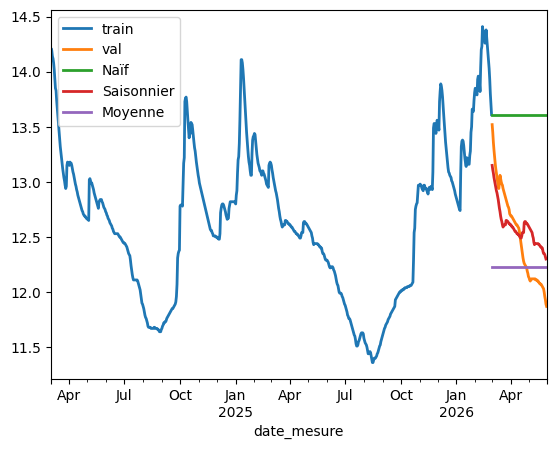

In [14]:
from darts.models import NaiveSeasonal, NaiveMean, NaiveDrift
from darts.metrics import mae, rmse, mape, r2_score

# --- Baseline 1 : Naïf → prédit toujours la dernière valeur observée ---
model_naive = NaiveSeasonal(K=1)
model_naive.fit(ts_train)
pred_naive = model_naive.predict(90)

# --- Baseline 2 : Saisonnier → même jour l'année dernière ---
model_seasonal = NaiveSeasonal(K=365)
model_seasonal.fit(ts_train)
pred_seasonal = model_seasonal.predict(90)

# --- Baseline 3 : Moyenne → prédit toujours la moyenne historique ---
model_mean = NaiveMean()
model_mean.fit(ts_train)
pred_mean = model_mean.predict(90)

# --- Comparaison ---
print(f"{'Modèle':<20} {'MAE':>6} {'RMSE':>6} {'MAPE':>7} {'R²':>6}")
print("-" * 50)
for name, pred in [
    ("Naïf",       pred_naive),
    ("Saisonnier", pred_seasonal),
    ("Moyenne",    pred_mean),
]:
    print(f"{name:<20} {mae(ts_val[:90], pred):>6.3f} {rmse(ts_val[:90], pred):>6.3f} {mape(ts_val[:90], pred):>6.2f}% {r2_score(ts_val[:90], pred):>6.3f}")

# --- Visualisation ---
ts_train[-730:].plot(label="train")
ts_val.plot(label="val")
pred_naive.plot(label="Naïf")
pred_seasonal.plot(label="Saisonnier")
pred_mean.plot(label="Moyenne")

---
## 5. LinearRegression avec lags

### Principe des lags dans Darts
Un **lag** est une valeur passee de la serie utilisee comme feature pour predire le futur.

```python
lags=[-365, -730]
```
Pour predire t+90, le modele utilise :
- `t-365` : niveau a la meme date l'an dernier
- `t-730` : niveau a la meme date il y a 2 ans

C'est la transcription ML de la saisonnalite annuelle des nappes.

### Premier test : 2 lags seulement
Volontairement simple pour etablir une reference ML avant d'enrichir.


<Axes: xlabel='date_mesure'>

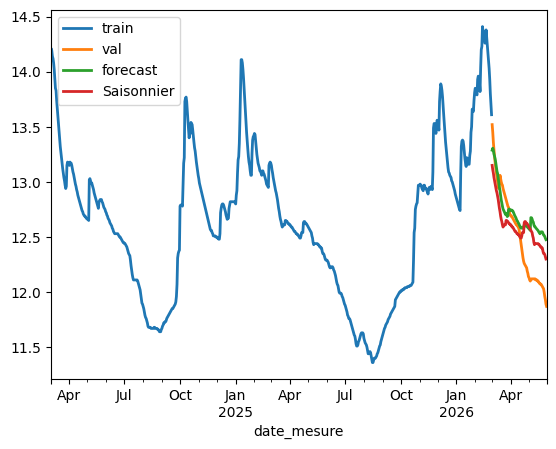

In [15]:
from darts.models import LinearRegressionModel

# Lags en journalier :
# -365  → même jour l'année dernière
# -730  → même jour il y a 2 ans
model = LinearRegressionModel(lags=[-365, -730])

model.fit(ts_train)

# On prédit 90 jours (≈ 3 mois)
pred = model.predict(90)

# Plot
ts_train[-730:].plot(label="train")
ts_val.plot(label="val")
pred.plot(label="forecast")
pred_seasonal.plot(label="Saisonnier")

### Metriques d'evaluation

| Metrique | Lecture |
|---|---|
| **MAE** | "En moyenne je me trompe de X metres" |
| **RMSE** | Penalise les grosses erreurs |
| **MAPE** | Erreur en % — lisible a l'oral |
| **R2** | 1=parfait / 0=pas mieux que la moyenne / <0=mauvais |


In [16]:
from darts.metrics import mae, rmse, mape, r2_score

print("=== QUALITÉ DU MODÈLE ===")
print(f"MAE   : {mae(ts_val[:90], pred):.3f} m")
print(f"RMSE  : {rmse(ts_val[:90], pred):.3f} m")
print(f"MAPE  : {mape(ts_val[:90], pred):.2f} %")
print(f"R²    : {r2_score(ts_val[:90], pred):.3f}")

=== QUALITÉ DU MODÈLE ===
MAE   : 0.252 m
RMSE  : 0.318 m
MAPE  : 2.06 %
R²    : 0.406


---
## 6. XGBoost

Modele d'ensemble base sur des arbres de decision (gradient boosting).
Plus puissant que la regression lineaire mais necessite **plus de features (lags)** pour exprimer son potentiel.

> Note : XGBoost n'est pas inclus par defaut dans Darts.
> Installer avec : `pip install xgboost` dans l'environnement `Projet_Hydrosense`


In [17]:
import xgboost
print(xgboost.__version__)

3.2.0


=== XGBoost ===
MAE   : 0.298 m
RMSE  : 0.376 m
MAPE  : 2.41 %
R²    : 0.166


<Axes: xlabel='date_mesure'>

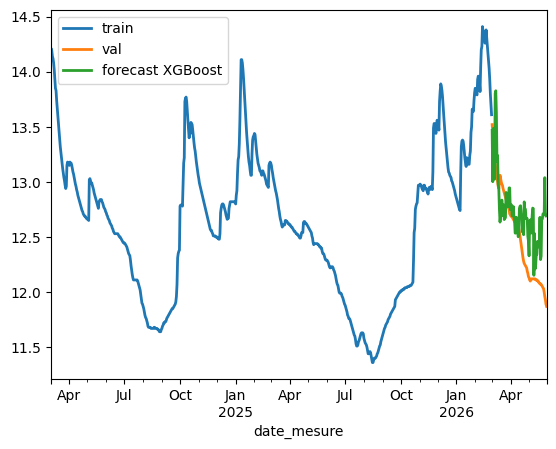

In [18]:
# XG Boost
# !pip install xgboost
from darts.models import XGBModel

lags=[-365, -730]

model_xgb = XGBModel(lags=lags, random_state=42)
model_xgb.fit(ts_train)
pred_xgb = model_xgb.predict(90)

# Métriques
print("=== XGBoost ===")
print(f"MAE   : {mae(ts_val[:90], pred_xgb):.3f} m")
print(f"RMSE  : {rmse(ts_val[:90], pred_xgb):.3f} m")
print(f"MAPE  : {mape(ts_val[:90], pred_xgb):.2f} %")
print(f"R²    : {r2_score(ts_val[:90], pred_xgb):.3f}")

# Visualisation
ts_train[-730:].plot(label="train")
ts_val.plot(label="val")
pred_xgb.plot(label="forecast XGBoost")

### Tableau comparatif — lags=[-365, -730]

```
Modele                    MAE    RMSE    MAPE      R2
Saisonnier               0.256   0.288   2.06%   0.512  <- baseline a battre
LinearRegression         0.252   0.318   2.06%   0.406
XGBoost                  0.298   0.376   2.41%   0.166  ECHEC
```

**Observations :**
- LinearRegression proche du Saisonnier sur MAE mais R2 plus faible
- XGBoost avec seulement 2 lags est decevant — pas assez de features

-> **Piste : enrichir les lags avec la memoire recente (30 derniers jours)**


In [19]:
## tableau comparatif

print(f"{'Modèle':<25} {'MAE':>6} {'RMSE':>6} {'MAPE':>7} {'R²':>7}")
print("-" * 55)
for name, pred in [
    ("Saisonnier",        pred_seasonal),
    ("LinearRegression",  pred),
    ("XGBoost",           pred_xgb),
]:
    print(f"{name:<25} {mae(ts_val[:90], pred):>6.3f} {rmse(ts_val[:90], pred):>6.3f} {mape(ts_val[:90], pred):>6.2f}% {r2_score(ts_val[:90], pred):>7.3f}")

Modèle                       MAE   RMSE    MAPE      R²
-------------------------------------------------------
Saisonnier                 0.256  0.288   2.06%   0.512
LinearRegression           0.252  0.318   2.06%   0.406
XGBoost                    0.298  0.376   2.41%   0.166


---
## 7. Enrichissement des lags — memoire recente

### Pourquoi ajouter les 30 derniers jours ?
Avec seulement [-365, -730], le modele ne voit pas la **tendance en cours** :
la nappe monte-t-elle ou descend-t-elle en ce moment ?

```python
lags = list(range(-1, -31, -1)) + [-365, -730]
# = [-1, -2, ..., -30, -365, -730]  -> 32 features
```

- `t-1` a `t-30` : memoire recente (tendance actuelle)
- `t-365`, `t-730` : ancres saisonnieres annuelles


Modèle                       MAE   RMSE    MAPE      R²
-------------------------------------------------------
Naïf                       1.088  1.164   8.81%  -6.974
Saisonnier                 0.256  0.288   2.06%   0.512
Moyenne                    0.396  0.505   3.09%  -0.500
LinearRegression           0.272  0.312   2.21%   0.425
XGBoost                    0.701  0.756   5.61%  -2.364


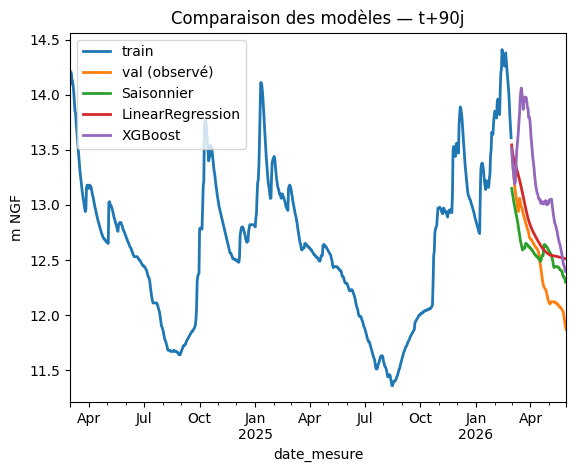

In [20]:
lags = list(range(-1, -31, -1)) + [-365, -730]

# Linear Regression
model_lr = LinearRegressionModel(lags=lags)
model_lr.fit(ts_train)
pred_lr = model_lr.predict(90)

# XGBoost
model_xgb = XGBModel(lags=lags, random_state=42)
model_xgb.fit(ts_train)
pred_xgb = model_xgb.predict(90)

# Tableau
print(f"{'Modèle':<25} {'MAE':>6} {'RMSE':>6} {'MAPE':>7} {'R²':>7}")
print("-" * 55)
for name, pred in [
    ("Naïf",              pred_naive),
    ("Saisonnier",        pred_seasonal),
    ("Moyenne",           pred_mean),
    ("LinearRegression",  pred_lr),
    ("XGBoost",           pred_xgb),
]:
    print(f"{name:<25} {mae(ts_val[:90], pred):>6.3f} {rmse(ts_val[:90], pred):>6.3f} {mape(ts_val[:90], pred):>6.2f}% {r2_score(ts_val[:90], pred):>7.3f}")

# Courbes
ts_train[-730:].plot(label="train")
ts_val.plot(label="val (observé)")
pred_seasonal.plot(label="Saisonnier")
pred_lr.plot(label="LinearRegression")
pred_xgb.plot(label="XGBoost")
plt.title("Comparaison des modèles — t+90j")
plt.ylabel("m NGF")
plt.legend()
plt.show()

---
## 8. Tuning XGBoost — lutte contre l'overfitting

XGBoost avec 32 lags overfitte : il memorise le train mais generalise mal sur le val.

**Parametres anti-overfitting :**

| Parametre | Valeur | Effet |
|---|---|---|
| `n_estimators` | 100 | Moins d'arbres -> moins de memorisation |
| `max_depth` | 3 | Arbres moins profonds -> moins de complexite |
| `learning_rate` | 0.05 | Apprentissage lent -> meilleure generalisation |
| `subsample` | 0.8 | 80% des donnees par arbre -> plus robuste |
| `colsample_bytree` | 0.8 | 80% des features par arbre -> plus robuste |


Modèle                       MAE   RMSE    MAPE      R²
-------------------------------------------------------
Saisonnier                 0.256  0.288   2.06%   0.512
LinearRegression           0.272  0.312   2.21%   0.425
XGBoost base               0.701  0.756   5.61%  -2.364
XGBoost tuned              0.764  0.852   6.21%  -3.274


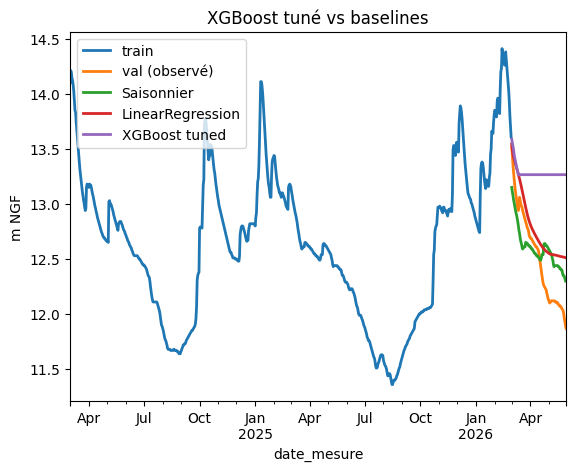

In [21]:
from darts.models import XGBModel
from darts.metrics import mae, rmse, mape, r2_score

lags = list(range(-1, -31, -1)) + [-365, -730]

# Paramètres anti-overfitting
model_xgb_tuned = XGBModel(
    lags=lags,
    n_estimators=100,      # moins d'arbres
    max_depth=3,           # arbres moins profonds
    learning_rate=0.05,    # apprentissage plus lent
    subsample=0.8,         # 80% des données par arbre
    colsample_bytree=0.8,  # 80% des features par arbre
    random_state=42,
)

model_xgb_tuned.fit(ts_train)
pred_xgb_tuned = model_xgb_tuned.predict(90)

print(f"{'Modèle':<25} {'MAE':>6} {'RMSE':>6} {'MAPE':>7} {'R²':>7}")
print("-" * 55)
for name, pred in [
    ("Saisonnier",        pred_seasonal),
    ("LinearRegression",  pred_lr),
    ("XGBoost base",      pred_xgb),
    ("XGBoost tuned",     pred_xgb_tuned),
]:
    print(f"{name:<25} {mae(ts_val[:90], pred):>6.3f} {rmse(ts_val[:90], pred):>6.3f} {mape(ts_val[:90], pred):>6.2f}% {r2_score(ts_val[:90], pred):>7.3f}")

ts_train[-730:].plot(label="train")
ts_val.plot(label="val (observé)")
pred_seasonal.plot(label="Saisonnier")
pred_lr.plot(label="LinearRegression")
pred_xgb_tuned.plot(label="XGBoost tuned")
plt.title("XGBoost tuné vs baselines")
plt.ylabel("m NGF")
plt.legend()
plt.show()

---
## Bilan de la session — Resultats finaux

```
Modele                    MAE    RMSE    MAPE      R2
-------------------------------------------------------
Naif                     1.088   1.164   8.81%  -6.974  ECHEC
Moyenne                  0.396   0.505   3.09%  -0.500  ECHEC
XGBoost base             0.701   0.756   5.61%  -2.364  ECHEC
XGBoost tuned            0.764   0.852   6.21%  -3.274  ECHEC
LinearRegression         0.272   0.312   2.21%   0.425
Saisonnier               0.256   0.288   2.06%   0.512  <- MEILLEUR
```

### Conclusions
- Donnees propres : 11 807 jours sans trou, outliers conserves (1995, 2003)
- Le baseline **Saisonnier** reste le modele a battre (R2=0.512)
- La **LinearRegression** est proche mais ne le bat pas encore
- **XGBoost overfitte** sans covariables meteo — le signal de la nappe seule ne suffit pas

### Pourquoi XGBoost echoue sans covariables ?
XGBoost est puissant mais gourmand en signal. Sans precipitations ni ETP,
il n'a que l'historique de la nappe — et il memorise au lieu de generaliser.

---

## Prochaines etapes

1. **Covariables meteo** (precipitations + ETP) -> levier le plus fort hydrologiquement
   - Les nappes reagissent aux pluies avec 4-12 semaines de decalage
   - `lags_past_covariates=[-1, -4, -8, -13, -26, -52]`

2. **Backtesting temporel** avec `historical_forecasts()` pour valider la robustesse sur plusieurs annees

3. **RandomForest** comme alternative a XGBoost (moins sensible a l'overfitting)

4. **Previsions probabilistes** (`likelihood="quantile"`) pour intervalles de confiance dans le Streamlit

5. **Prophet**



In [22]:
# test prophet

In [23]:
import sys
!{sys.executable} -m pip show prophet

Name: prophet
Version: 1.3.0
Summary: Automatic Forecasting Procedure
Home-page: https://facebook.github.io/prophet/
Author: 
Author-email: "Sean J. Taylor" <sjtz@pm.me>, Ben Letham <bletham@fb.com>
License: MIT
Location: /home/yanns/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages
Requires: cmdstanpy, holidays, importlib_resources, matplotlib, numpy, pandas, tqdm
Required-by: 


In [24]:
import prophet
print(prophet.__version__)

1.3.0


/home/yanns/.pyenv/versions/3.10.6/envs/Projet_Hydrosense/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


11:14:01 - cmdstanpy - INFO - Chain [1] start processing
11:14:05 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet ===
MAE   : 0.629 m
RMSE  : 0.675 m
MAPE  : 5.09 %
R²    : -1.684


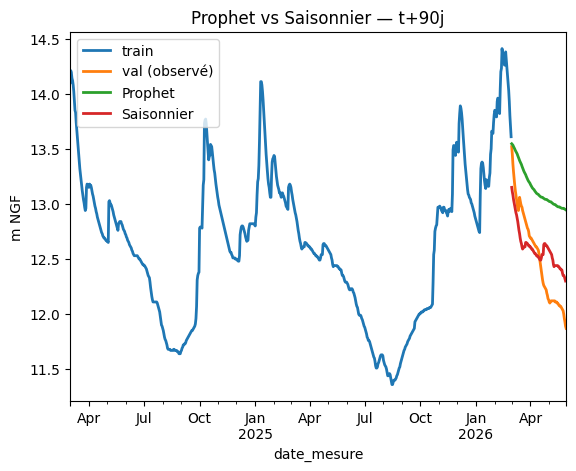

In [25]:
from darts.models import Prophet
from darts.metrics import mae, rmse, mape, r2_score

model_prophet = Prophet()
model_prophet.fit(ts_train)
pred_prophet = model_prophet.predict(90)

print("=== Prophet ===")
print(f"MAE   : {mae(ts_val[:90], pred_prophet):.3f} m")
print(f"RMSE  : {rmse(ts_val[:90], pred_prophet):.3f} m")
print(f"MAPE  : {mape(ts_val[:90], pred_prophet):.2f} %")
print(f"R²    : {r2_score(ts_val[:90], pred_prophet):.3f}")

ts_train[-730:].plot(label="train")
ts_val.plot(label="val (observé)")
pred_prophet.plot(label="Prophet")
pred_seasonal.plot(label="Saisonnier")
plt.title("Prophet vs Saisonnier — t+90j")
plt.ylabel("m NGF")
plt.legend()
plt.show()

11:15:24 - cmdstanpy - INFO - Chain [1] start processing
11:15:30 - cmdstanpy - INFO - Chain [1] done processing


=== Prophet tuned ===
MAE   : 0.364 m
RMSE  : 0.413 m
MAPE  : 2.96 %
R²    : -0.006


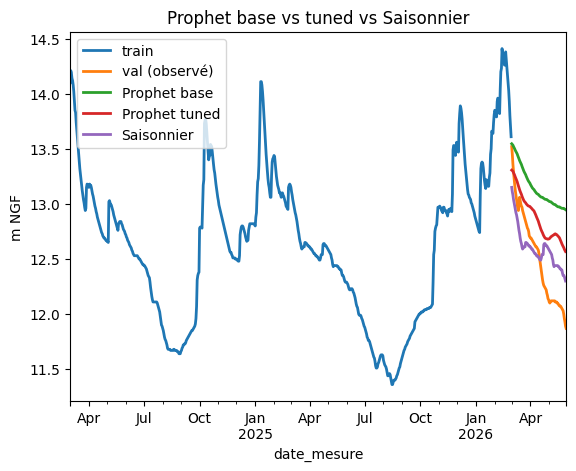

In [26]:
from darts.models import Prophet
from darts.metrics import mae, rmse, mape, r2_score

model_prophet_tuned = Prophet(
    add_seasonalities={
        "name": "annuelle",
        "seasonal_periods": 365,
        "fourier_order": 10,
    }
)

model_prophet_tuned.fit(ts_train)
pred_prophet_tuned = model_prophet_tuned.predict(90)

print("=== Prophet tuned ===")
print(f"MAE   : {mae(ts_val[:90], pred_prophet_tuned):.3f} m")
print(f"RMSE  : {rmse(ts_val[:90], pred_prophet_tuned):.3f} m")
print(f"MAPE  : {mape(ts_val[:90], pred_prophet_tuned):.2f} %")
print(f"R²    : {r2_score(ts_val[:90], pred_prophet_tuned):.3f}")

ts_train[-730:].plot(label="train")
ts_val.plot(label="val (observé)")
pred_prophet.plot(label="Prophet base")
pred_prophet_tuned.plot(label="Prophet tuned")
pred_seasonal.plot(label="Saisonnier")
plt.title("Prophet base vs tuned vs Saisonnier")
plt.ylabel("m NGF")
plt.legend()
plt.show()